In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from scipy.stats import spearmanr

from matplotlib.patches import Rectangle



In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    527 non-null    float64
 1   ztfname                           527 non-null    object 
 2   ZTF_redshift                      527 non-null    float64
 3   ZTF_redshift_err                  527 non-null    float64
 4   ZTF_source                        527 non-null    object 
 5   ZTF_t0                            527 non-null    float64
 6   ZTF_x0                            527 non-null    float64
 7   ZTF_x1                            527 non-null    float64
 8   ZTF_c                             527 non-null    float64
 9   ZTF_t0_err                        527 non-null    float64
 10  ZTF_x0_err                        527 non-null    float64
 11  ZTF_x1_err                        527 non-null    float64
 12  ZTF_c_er

In [3]:
FEATURE_COLS = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "ZTF_x1",
    "ZTF_c",
]

# Check for NaNs in every column
print(df.isna().sum()[df.isna().sum() > 0])

# Check for infinities
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nInfinities:")
print((np.isinf(df[numeric_cols])).sum()[np.isinf(df[numeric_cols]).sum() > 0])

# Check for zeros in columns that shouldn't be zero
print("\nZero counts in key features:")
for col in FEATURE_COLS:
    n_zero = (df[col] == 0).sum()
    if n_zero > 0:
        print(f"  {col}: {n_zero} zeros ({100*n_zero/len(df):.1f}%)")

# Basic sanity ranges
print("\nFeature ranges:")
print(df[FEATURE_COLS].describe().round(3).to_string())

ZTF_sub_type                   85
ZTF_iau_name                   14
ZTF_mass_global                 2
ZTF_mass_err_global             2
ZTF_restframe_gz_global         2
ZTF_restframe_gz_err_global     2
ZTF_mass_local                  6
ZTF_mass_err_local              2
ZTF_restframe_gz_local          6
ZTF_restframe_gz_err_local      6
dtype: int64

Infinities:
Series([], dtype: int64)

Zero counts in key features:
  DESI_FASTSPEC_SFR: 167 zeros (31.7%)

Feature ranges:
       DESI_FASTSPEC_LOGMSTAR  DESI_FASTSPEC_SFR  DESI_FASTSPEC_VDISP  DESI_FASTSPEC_DN4000  DESI_FASTSPEC_g_minus_r  DESI_FASTSPEC_AGE   ZTF_x1    ZTF_c
count                 527.000            527.000              527.000               527.000                  527.000            527.000  527.000  527.000
mean                   10.063              0.253              157.437                 1.532                    0.693              8.385   -0.019    0.031
std                     0.782              0.433             

# Important Note About `scipy.spearmanr` function #

Returns:
resSignificanceResult
An object containing attributes:

statistic
float or ndarray (2-D square)
Spearman correlation matrix or correlation coefficient (if only 2 variables are given as parameters). Correlation matrix is square with length equal to total number of variables (columns or rows) in a and b combined.

pvalue
float
The p-value for a hypothesis test whose null hypothesis is that two samples have no ordinal correlation. See alternative above for alternative hypotheses. pvalue has the same shape as statistic.

## Correlation Matrix Analysis — Notes for Paper

**Purpose:** This Spearman ρ correlation matrix goes in §3.1 (Methods → Feature Screening) as motivation for why ML is needed.

### Key Takeaways

**2. x0 and t0 carry no host-galaxy physics — exclude from ML training:**
- x0 is just a distance proxy (ρ = −0.84 with both redshifts). Already absorbed into μ_obs.
- t0 is the calendar date of maximum light — correlated with nothing (all |ρ| ≤ 0.08).

**3. x1 has strong cross-correlations with DESI host properties:**
- x1 vs log M★: −0.40
- x1 vs DN4000: −0.41
- x1 vs g−r: −0.48
- x1 vs Age: −0.39

This is the known stretch-age relation: massive, old, red hosts produce faster-declining (low x1) SNe Ia. The Tripp equation applies one global α regardless of host environment. If α actually varies with host mass or age, the linear correction is systematically wrong → leftover error in Hubble residuals. **This is the cross-term our paper is designed to detect.**

**4. c has weaker but nonzero cross-correlations with hosts:**
- c vs log M★: 0.20
- c vs g−r: 0.15

This is the dust correlation: more massive galaxies have more dust → redder SNe. Same argument applies — if β varies with host properties (Kelsey+2023 found ~3σ differences in β between high/low mass environments), the linear Tripp correction leaves residual bias.

**5. DESI host properties are strongly intercorrelated (the "tangle"):**
- log M★ vs g−r: 0.76
- log M★ vs Age: 0.75
- DN4000 vs g−r: 0.79
- DN4000 vs Age: 0.63
- g−r vs Age: 0.74
- log M★ vs DN4000: 0.64

These all trace the galaxy mass-metallicity-age sequence. A univariate correction (e.g., mass step at log M★ = 10) cannot disentangle which property is actually driving the Hubble residual bias because they all move together. **This is why nonparametric ML is needed.**

**6. SFR and σ_v are the independent ones:**
Both are weakly correlated with the log M★ / DN4000 / g−r / Age block (|ρ| ≤ 0.26). They may carry independent information about the SN Ia progenitor environment that the other four DESI properties don't capture.

### Decisions for the Paper
- **Include in ML training:** c, x1, log M★, SFR, σ_v, DN4000, g−r, Age, z (9 features)
- **Exclude from ML training:** x0 (distance proxy), t0 (no information)
- **This figure goes in:** §3.1 Methods (Feature Screening), NOT Results
- **The argument it supports:** Linear corrections can't handle intercorrelated features with potential cross-terms → need ML

# Focused In Analysis # - ZTF Results 

In [6]:
# ──────────────────────────────────────────────────────────────
# Define features grouped by source
# ──────────────────────────────────────────────────────────────

#Definitions of the actual features we want to compute. 
ztf_cols   = ["ZTF_c", "ZTF_x1", "ZTF_x0", "ZTF_t0", "ZTF_redshift"]

desi_cols   = ["DESI_FASTSPEC_LOGMSTAR", "DESI_FASTSPEC_SFR", "DESI_FASTSPEC_VDISP",
               "DESI_FASTSPEC_DN4000", "DESI_FASTSPEC_g_minus_r", "DESI_FASTSPEC_AGE",
               "DESI_METADATA_Z"]

# Stylized Typesetting for the plots.
ztf_labels = [r"$c$", r"$x_1$", r"$x_0$", r"$t_0$", r"$z_{\rm ZTF}$"]
desi_labels = [r"$\log M_\star$", "SFR", r"$\sigma_v$", r"$D_n4000$", "SDSS  g - r", "Age",
               r"$z_{\rm DESI}$"]

ztf_plus_host_cols = ztf_cols + desi_cols
all_labels   = ztf_labels + desi_labels

# ──────────────────────────────────────────────────────────────
# Compute Spearman rho and p-values, slice to cross-block
# ──────────────────────────────────────────────────────────────
# The scipy spearman rho function computes pairwise ρ between all variables fed into it.  
# Note that in this case its doing a 12x12 matrix of all DESI host galaxy collumns and all ZTF light-curve columns.
# There is no way to get the correlations between just the ZTF and DESI features
#  and we are forced to compute the full matrix first due to functional limiatiotns.
rho_matrix, pval_matrix = spearmanr(df[ztf_plus_host_cols])


# These need to be converted to data frames for the seaborn package,
# and this also helps us keep track of feature names and use LaTex formatting for the labels in the heatmap.
# assigns the string index "all_labels" to the collumns of teh data frame.
# Essentiallly just repalces all the collumns listed as "all_labels" with more nicely formated labels.
# Note that the order of labels have to match the order of the collumns in the data frame, 
# which is determined by the order of features as defined above.

spearman_corr_full = pd.DataFrame(rho_matrix, index=all_labels, columns=all_labels)
spearman_pval_full = pd.DataFrame(pval_matrix, index=all_labels, columns=all_labels)

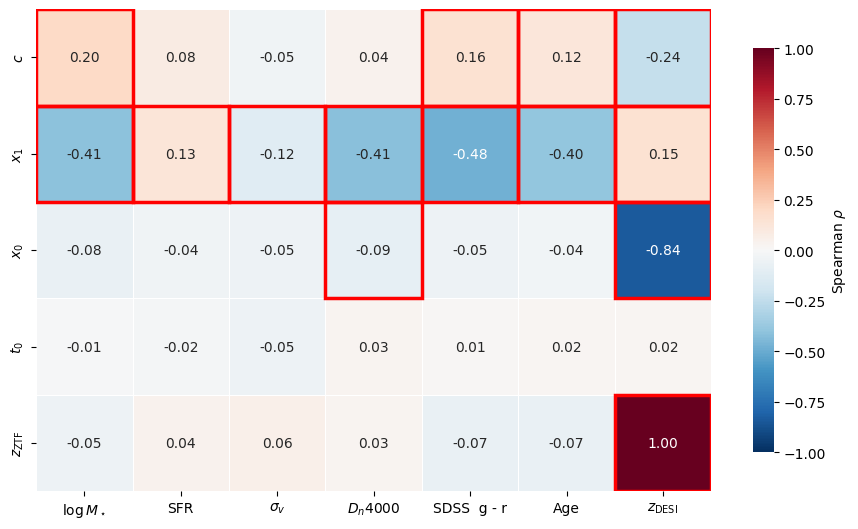

In [7]:
spearman_corr_full = pd.DataFrame(rho_matrix, index=all_labels, columns=all_labels)
spearman_pval_full = pd.DataFrame(pval_matrix, index=all_labels, columns=all_labels)

# Pulls only the entries where the row is a ZTF feature and the column is a DESI feature.
# .loc is the way to get index via label name. 
spearman_corr = spearman_corr_full.loc[ztf_labels, desi_labels]
spearman_pval = spearman_pval_full.loc[ztf_labels, desi_labels]

# ──────────────────────────────────────────────────────────────
# Figure 1: Spearman rho heatmap with red outlines on p<0.05
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

seaborn.heatmap(
    # Describe the data set to plot. 
    spearman_corr, # Our limited size data fram
    annot=True, fmt=".2f", # Write each numerica value in the cell, with 2 decimal places.
    cmap="RdBu_r", # Color coding choice. _r swaps which end is red.

    # Color Bar and Color Scale
    vmin=-1, vmax=1, center=0, # ranges form the limits of the spearman rho.
    square=True, 
    linewidths=0.5, # Thin white separator lines between squares.
    cbar_kws={"label": r"Spearman $\rho$", "shrink": 0.8}, # Colorbar label.
    ax=ax, # necesary for the rectangle overlay later. If we don't add this we won't be able to draw.
)

# Standard p-value cutoff. 
sig_mask = spearman_pval.values < 0.05 # Boolena criterion for our mask.

# For the location where our p-values are less than 0.05. 
for i, j in zip(*np.where(sig_mask)):

    # Add patch command simply draws a rectangle anchored at i,j with width and height of 1.
    # lw controls the line width of said rectangle. 
    ax.add_patch(Rectangle((j, i), 1, 1,
                           fill=False, edgecolor="red", lw=2.5))

fig.tight_layout()
fig.savefig("figures/ztf_desi_spearman_corr.pdf", bbox_inches="tight", dpi=300)
plt.show()

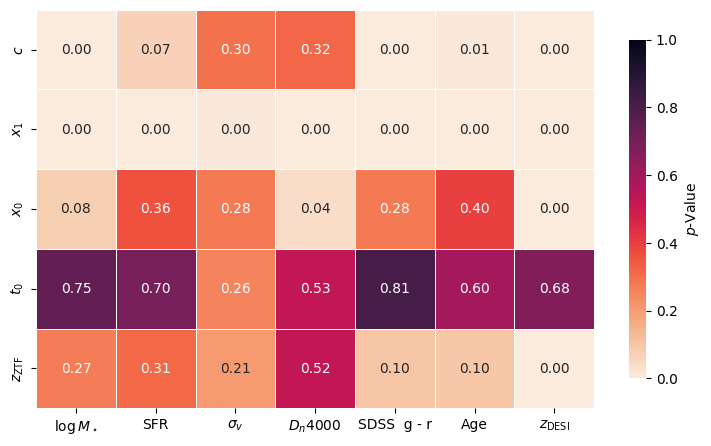

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))


seaborn.heatmap(
    # Describe the data set to plot. 
    spearman_pval, # Our limited size data frame
    annot=True, fmt=".2f", # Write each numerica value in the cell, with 2 decimal places.
    cmap="rocket_r", # Color coding choice. _r swaps which end is red.

    # Color Bar and Color Scale
    vmin=0, vmax=1, # ranges form the limits of p values (note different from Spearman rho).
    square=True, 
    linewidths=0.5, # Thin white separator lines between squares.
    cbar_kws={"label": r"$p$-Value", "shrink": 0.8}, # Colorbar label.
    ax=ax, # necesary for the rectangle overlay later. If we don't add this we won't be able to draw.
)

fig.savefig("figures/ztf_desi_spearman_pvals.pdf", bbox_inches="tight", dpi=300)

plt.show()

[[ True False False False False]
 [ True  True False False False]
 [ True  True  True False False]
 [ True  True  True  True False]
 [ True  True  True  True  True]]


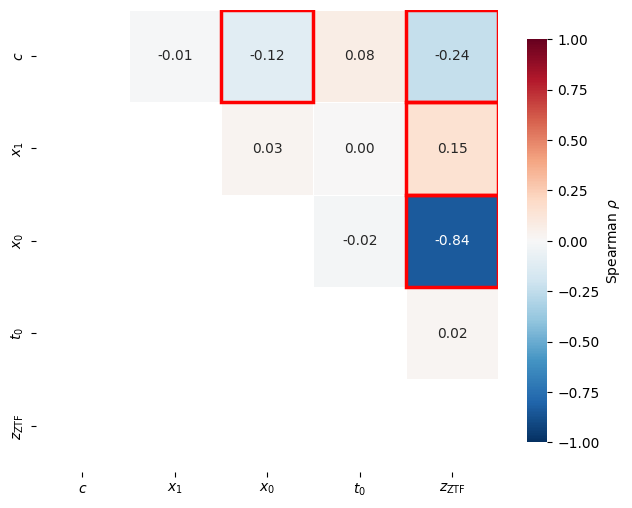

In [9]:
# Pulls only the entries where both the row and column are ZTF features.
# .loc is the way to get index via label name. 
spearman_corr = spearman_corr_full.loc[ztf_labels, ztf_labels]
spearman_pval = spearman_pval_full.loc[ztf_labels, ztf_labels]

# Mask the lower triangle + diagonal: the matrix is symmetric, so the lower
# triangle duplicates the upper, and the diagonal is trivially 1.0 by construction. 
# np.tril gives a boolean array that is True on seaborn hides
# cells where the mask is True.
mask = np.tril(np.ones_like(spearman_corr, dtype=bool))
print(mask)

# ──────────────────────────────────────────────────────────────
# Figure: ZTF × ZTF Spearman rho heatmap with red outlines on p<0.05
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

seaborn.heatmap(
    # Describe the data set to plot. 
    spearman_corr, # Our limited size data fram
    mask=mask, # Hide lower triangle and diagonal. Data not shown when Mask is True.
    annot=True, fmt=".2f", # Write each numerica value in the cell, with 2 decimal places.
    cmap="RdBu_r", # Color coding choice. _r swaps which end is red.

    # Color Bar and Color Scale
    vmin=-1, vmax=1, center=0, # ranges form the limits of the spearman rho.
    square=True, 
    linewidths=0.5, # Thin white separator lines between squares.
    cbar_kws={"label": r"Spearman $\rho$", "shrink": 0.8}, # Colorbar label.
    ax=ax, # necesary for the rectangle overlay later. If we don't add this we won't be able to draw.
)

# Standard p-value cutoff. Exclude masked cells so we don't outline hidden ones. 
# sig_mask is True where p-value < 0.05 and False where p-value >= 0.05, but also False 
# where mask is True which corresponds to the data in the daigonal and lower triangle that we have hidden.
sig_mask = (spearman_pval.values < 0.05) & ~mask #

# For the location where our p-values are less than 0.05. 
for i, j in zip(*np.where(sig_mask)):

    # Add patch command simply draws a rectangle anchored at i,j with width and height of 1.
    # lw controls the line width of said rectangle. 
    ax.add_patch(Rectangle((j, i), 1, 1,
                           fill=False, edgecolor="red", lw=2.5))

fig.tight_layout()
fig.savefig("figures/ztf_ztf_spearman_corr.pdf", bbox_inches="tight", dpi=300)
plt.show()

[[ True False False False False]
 [ True  True False False False]
 [ True  True  True False False]
 [ True  True  True  True False]
 [ True  True  True  True  True]]


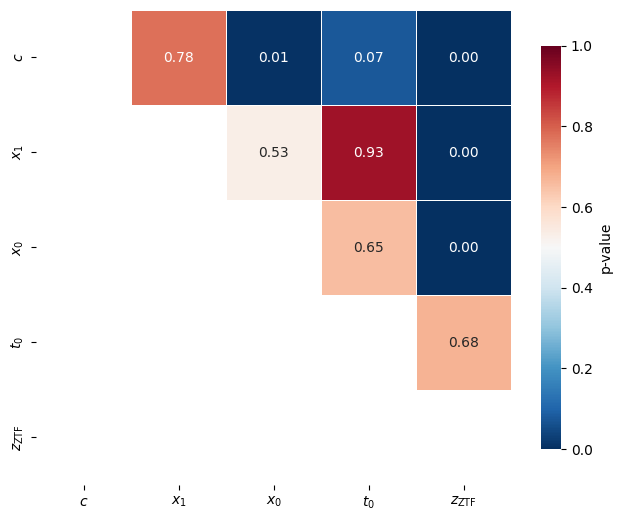

In [10]:
# Pulls only the entries where both the row and column are ZTF features.
# .loc is the way to get index via label name. 
spearman_corr = spearman_corr_full.loc[ztf_labels, ztf_labels]
spearman_pval = spearman_pval_full.loc[ztf_labels, ztf_labels]

# Mask the lower triangle + diagonal: the matrix is symmetric, so the lower
# triangle duplicates the upper, and the diagonal is trivially 1.0 by construction. 
# np.tril gives a boolean array that is True on seaborn hides
# cells where the mask is True.
mask = np.tril(np.ones_like(spearman_corr, dtype=bool))
print(mask)

# ──────────────────────────────────────────────────────────────
# Figure: ZTF × ZTF Spearman rho heatmap with red outlines on p<0.05
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

seaborn.heatmap(
    # Describe the data set to plot. 
    spearman_pval, # Our limited size data fram
    mask=mask, # Hide lower triangle and diagonal. Data not shown when Mask is True.
    annot=True, fmt=".2f", # Write each numerica value in the cell, with 2 decimal places.
    cmap="RdBu_r", # Color coding choice. _r swaps which end is red.

    # Color Bar and Color Scale
    vmin=0 , vmax=1, # ranges form the limits of the spearman rho.
    square=True, 
    linewidths=0.5, # Thin white separator lines between squares.
    cbar_kws={"label": r"p-value", "shrink": 0.8}, # Colorbar label.
    ax=ax, # necesary for the rectangle overlay later. If we don't add this we won't be able to draw.
)

fig.tight_layout()
fig.savefig("figures/ztf_ztf_spearman_corr.pdf", bbox_inches="tight", dpi=300)
plt.show()


In [ ]:
# # GrandFathered Code #

# # ──────────────────────────────────────────────────────────────
# # Define features grouped by source
# # ──────────────────────────────────────────────────────────────

# # --- ZTF DR2 light-curve parameters ---
# ztf_cols   = ["ZTF_c", "ZTF_x1", "ZTF_x0", "ZTF_t0", "ZTF_redshift"]
# ztf_labels = [r"$c$", r"$x_1$", r"$x_0$", r"$t_0$", r"$z_{\rm ZTF}$"]

# # --- DESI DR1 FastSpecFit host galaxy properties ---
# desi_cols   = ["DESI_FASTSPEC_LOGMSTAR", "DESI_FASTSPEC_SFR", "DESI_FASTSPEC_VDISP",
#                "DESI_FASTSPEC_DN4000", "DESI_FASTSPEC_g_minus_r", "DESI_FASTSPEC_AGE",
#                "DESI_METADATA_Z"]
# desi_labels = [r"$\log M_\star$", "SFR", r"$\sigma_v$", r"$D_n4000$", r"$g - r$", "Age",
#                r"$z_{\rm DESI}$"]

# # Combined: ZTF first, then DESI
# feature_cols   = ztf_cols + desi_cols
# display_labels = ztf_labels + desi_labels

# # The following are used to keep track of where the dividing line should go 
# # in our heatmap. 
# n_ztf  = len(ztf_cols)
# n_desi = len(desi_cols)
# n_all  = n_ztf + n_desi

# # ──────────────────────────────────────────────────────────────
# # Compute Spearman rho and p-values via scipy
# # ──────────────────────────────────────────────────────────────

# # Every cell in the returned matrix is the correlation between feature i and feature j. 
# # P value same thing.
# rho_matrix, pval_matrix = spearmanr(df[feature_cols])


# # Converts to data frame (required for the seaborn package).
# # Nice thing here is that it helps us keep track of feature names and use
# # LaTex formatting for the labels in the heatmap. 
# # spearman
# spearman_corr = pd.DataFrame(rho_matrix, index=display_labels, columns=display_labels)
# spearman_pval = pd.DataFrame(pval_matrix, index=display_labels, columns=display_labels)

# # Mask the lower triangle
# # creates new array np.ones_like, but only with booleans. Default True values.
# # tril = lower triangle. So we get a mask that is True for the lower triangle and False for the upper triangle.
# mask = np.tril(np.ones_like(spearman_corr, dtype=bool))
# print(mask)

# fig, ax = plt.subplots(figsize=(11, 9))

# seaborn.heatmap(
#     spearman_corr,
#     mask=mask, # in seaborn heatmaps, True means hide this cell. 
#     annot=True,
#     fmt=".2f",
#     cmap="RdBu_r",
#     vmin=-1,
#     vmax=1,
#     center=0,
#     square=True,
#     linewidths=0.5,
#     cbar_kws={"label": r"Spearman $\rho$", "shrink": 0.8},
#     ax=ax,
# )

# # Thick lines separating ZTF and DESI blocks
# ax.axhline(n_ztf, color="black", linewidth=2)
# ax.axvline(n_ztf, color="black", linewidth=2)

# # Group labels — left margin
# ax.text(-0.8, n_ztf / 2, "ZTF DR2",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         rotation=90, transform=ax.transData)
# ax.text(-0.8, n_ztf + n_desi / 2, "DESI DR1",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         rotation=90, transform=ax.transData)

# # Group labels — bottom margin
# ax.text(n_ztf / 2, n_all + 0.8, "ZTF DR2",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         transform=ax.transData)
# ax.text(n_ztf + n_desi / 2, n_all + 0.8, "DESI DR1",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         transform=ax.transData)

# ax.set_title("Feature Correlation Matrix", fontsize=14, pad=12)
# fig.tight_layout()
# plt.show()


# fig, ax = plt.subplots(figsize=(11, 9))

# seaborn.heatmap(
#     spearman_pval,
#     mask=mask, # in seaborn heatmaps, True means hide this cell. 
#     annot=True,
#     fmt=".2f",
#     cmap="RdBu_r",
#     vmin=-1,
#     vmax=1,
#     center=0,
#     square=True,
#     linewidths=0.5,
#     cbar_kws={"label": r"P-Value", "shrink": 0.8},
#     ax=ax,
# )

# # Thick lines separating ZTF and DESI blocks
# ax.axhline(n_ztf, color="black", linewidth=2)
# ax.axvline(n_ztf, color="black", linewidth=2)

# # Group labels — left margin
# ax.text(-0.8, n_ztf / 2, "ZTF DR2",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         rotation=90, transform=ax.transData)
# ax.text(-0.8, n_ztf + n_desi / 2, "DESI DR1",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         rotation=90, transform=ax.transData)

# # Group labels — bottom margin
# ax.text(n_ztf / 2, n_all + 0.8, "ZTF DR2",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         transform=ax.transData)
# ax.text(n_ztf + n_desi / 2, n_all + 0.8, "DESI DR1",
#         ha="center", va="center", fontsize=11, fontweight="bold",
#         transform=ax.transData)

# ax.set_title("Feature P-Value Matrix", fontsize=14, pad=12)
# fig.tight_layout()
# plt.show()